## Diabetes Predictions 

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.datasets import load_diabetes

In [23]:
dataset = load_diabetes()

In [24]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [25]:
X = pd.DataFrame(dataset.data,columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [26]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [27]:
y = dataset.target

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

<Axes: >

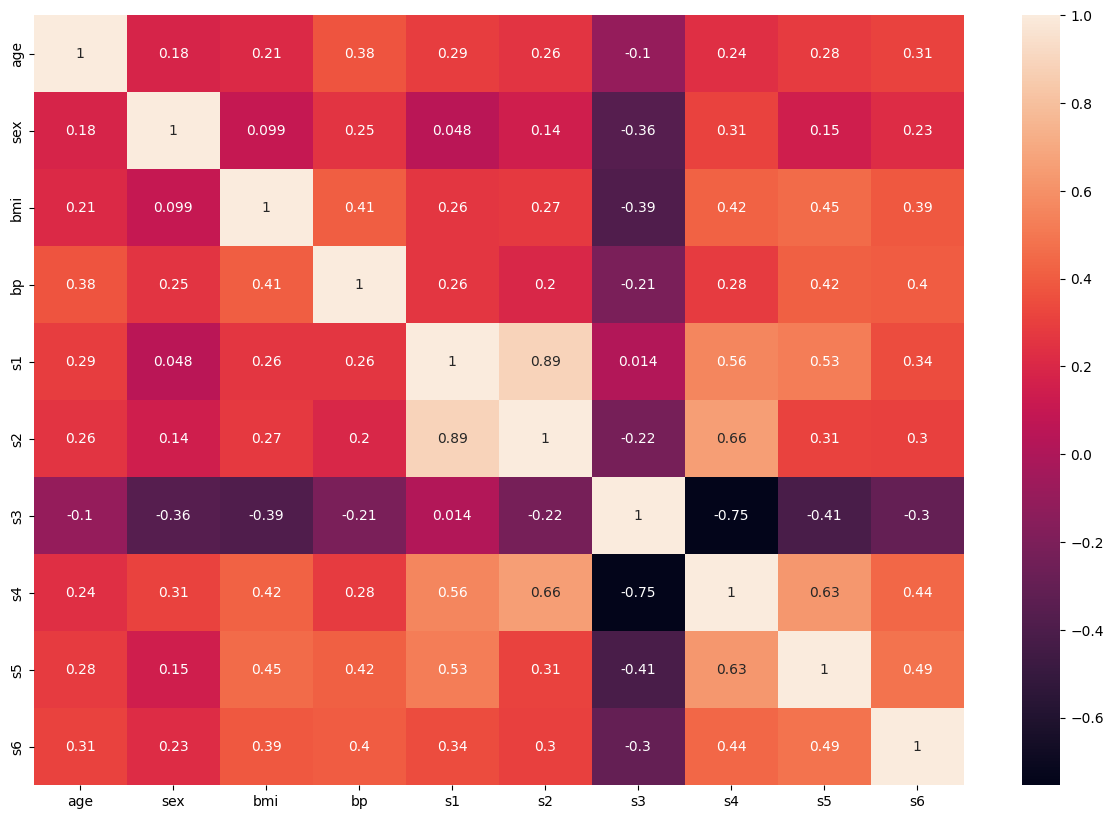

In [29]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [31]:
dtr = DecisionTreeRegressor()

In [32]:
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

[Text(0.583862147871169, 0.975, 'x[8] <= 0.022\nsquared_error = 6130.698\nsamples = 353\nvalue = 151.606'),
 Text(0.36426265140392733, 0.925, 'x[2] <= 0.005\nsquared_error = 4113.098\nsamples = 240\nvalue = 120.921'),
 Text(0.47406239963754815, 0.95, 'True  '),
 Text(0.19078902092126995, 0.875, 'x[6] <= 0.021\nsquared_error = 2467.151\nsamples = 178\nvalue = 102.815'),
 Text(0.06633671315837768, 0.825, 'x[8] <= -0.043\nsquared_error = 3122.957\nsamples = 100\nvalue = 115.77'),
 Text(0.027895026610387227, 0.775, 'x[9] <= -0.003\nsquared_error = 1964.604\nsamples = 24\nvalue = 86.25'),
 Text(0.014681592952835382, 0.725, 'x[9] <= -0.076\nsquared_error = 1003.75\nsamples = 20\nvalue = 75.5'),
 Text(0.00880895577170123, 0.675, 'x[2] <= -0.065\nsquared_error = 1379.556\nsamples = 3\nvalue = 120.667'),
 Text(0.005872637181134153, 0.625, 'x[8] <= -0.053\nsquared_error = 144.0\nsamples = 2\nvalue = 146.0'),
 Text(0.0029363185905670764, 0.575, 'squared_error = 0.0\nsamples = 1\nvalue = 134.0'),


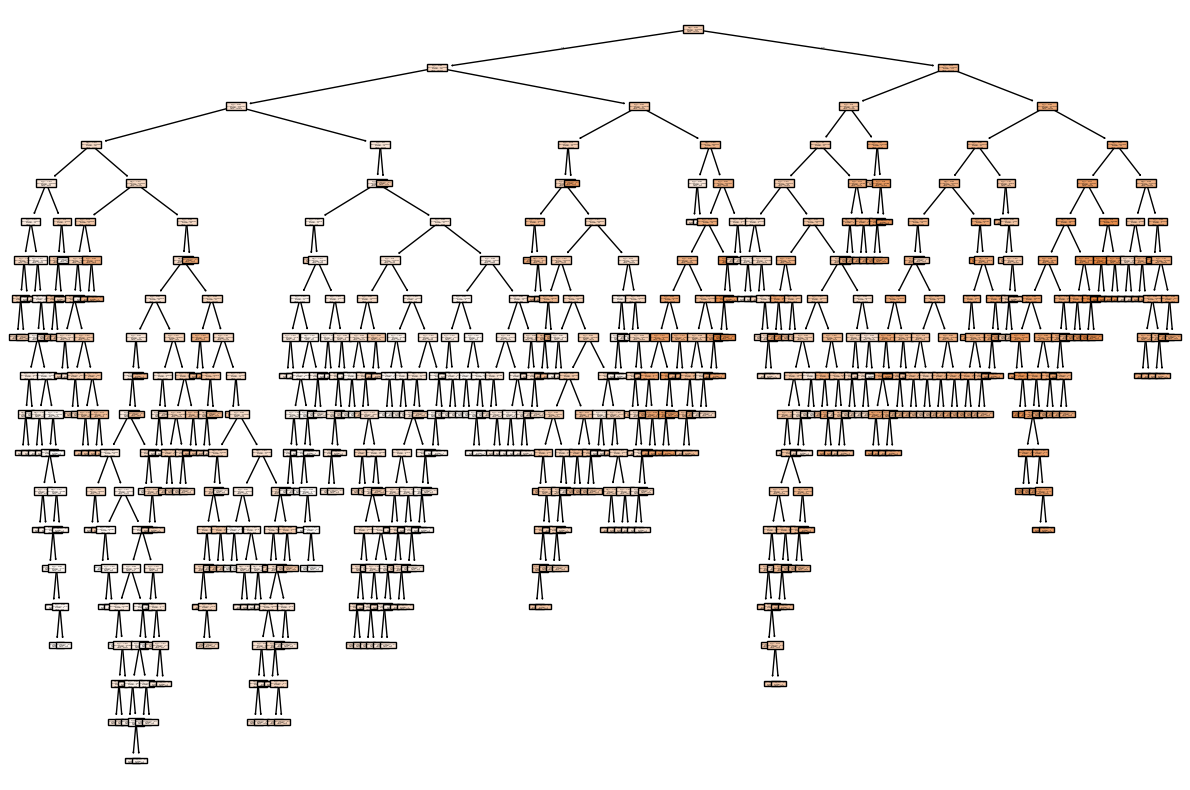

In [33]:
## Visualize Decision tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtr,filled=True)

In [34]:
y_pred = dtr.predict(X_test)

In [35]:
from sklearn.metrics import r2_score,mean_squared_error,confusion_matrix
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

-0.4106714434943255
7233.820224719101
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Hyperparameter Tuning

In [36]:
params ={
    'criterion' : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter' : ['best','random'],
    'max_depth' :[1,2,3,4,5,10,15,20,25],
    'max_features' :['auto','sqrt','log2'],
}

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
gcv = GridSearchCV(estimator=dtr,param_grid=params,cv=5,scoring='neg_mean_squared_error')

In [39]:
import warnings
warnings.filterwarnings('ignore')
gcv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [40]:
gcv.best_params_

{'criterion': 'poisson',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [41]:
y_pred1 = gcv.predict(X_test)

In [42]:
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

-0.4106714434943255
7233.820224719101
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
